In [1]:
import pandas as pd

df = pd.read_csv("StudentsPerformance.csv")

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


Dataset Shape:
(1000, 8)

First 5 Rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


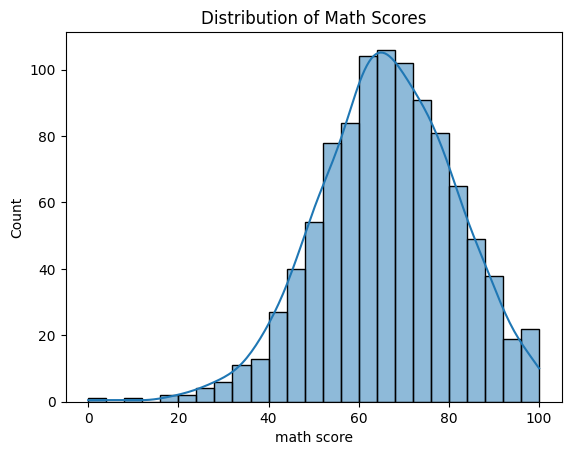

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['math score'], kde=True)
plt.title("Distribution of Math Scores")
plt.show()


In [3]:
print("\nMissing Values:")
print(df.isna().sum())



Missing Values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


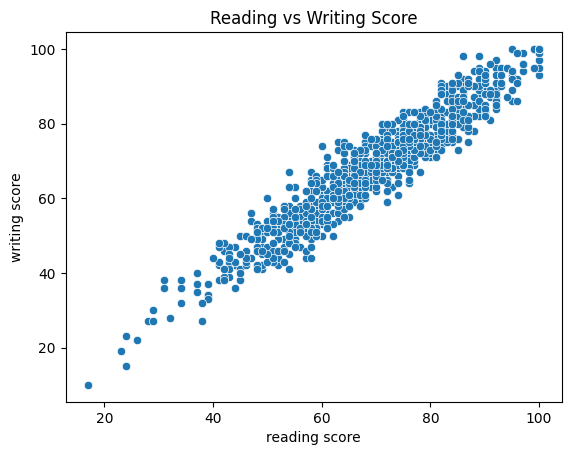

In [4]:
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title("Reading vs Writing Score")
plt.show()


In [5]:
print("Column Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Column Names:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

Data Types:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


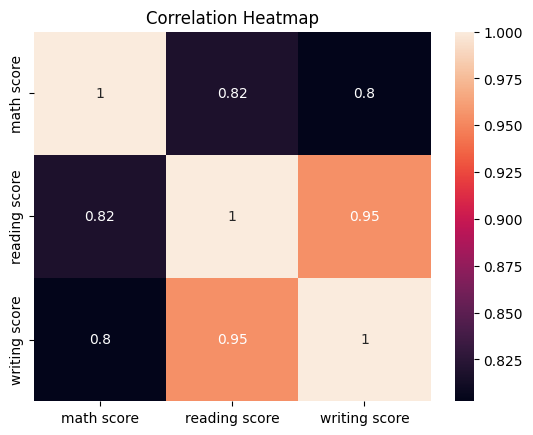

In [6]:
sns.heatmap(df[['math score','reading score','writing score']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()


## Problem Definition

This project uses the "Students Performance in Exams" dataset.  
The goal is to analyze student data and define a machine learning problem.

The main objective is to predict whether a student will pass or fail based on available features such as:
- gender  
- parental level of education  
- lunch type  
- test preparation course  
- exam scores  

Since the output is a category (pass or fail), this problem is defined as a **Classification Problem**.


### Problem Statement

This project analyzes the "Students Performance in Exams" dataset to define a machine learning problem. The goal is to predict student performance based on features such as gender, parental education level, lunch type, and test preparation course. This problem can be treated as a classification task by predicting whether a student will pass or fail based on exam scores.


In [9]:

print(df.isnull().sum())


print("Duplicate rows:", df.duplicated().sum())


print(df.dtypes)


print(df.describe())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Duplicate rows: 0
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100

In [10]:

df.fillna(df.mean(numeric_only=True), inplace=True)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [12]:

num_cols = ['math score','reading score','writing score']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]